## **P1 - Audit of dataset**  
This submission contains a runnable notebook demonstrating the audit of our selected data set for the course IDIG4120 *Digital Information Processing*.

### Task Description
*Describe how your data is actually represented, and test the assumptions everything later depends on. The
baseline you fix here is what P2 measures its compression against.*  
Format, array shape, data type, units, range and byte size.
 - [ ] Sampling rate or spacing. Say so where the concept does not apply, or is unknown.
 - [ ] One time or spatial view and one frequency view, both with labelled axes.
 - [ ] One transform or filtering experiment, with the prediction you made before running it.
 - [ ] One resampling or quantisation experiment that finds an artefact or a limitation.
 - [ ] A reproducible loader, and the baseline representation P2 will be measured against.
 - [ ] One Visual Informatics concern and one implementation, integrity or security concern that meet in this dataset.
 - [ ] Who did what, and the generative-AI declaration.

### 1.) **Pre audit dataset details:** (Repeat of P0)
 
 - **Name**: UrbanSound8k  
 - **Stable source**: Kaggle Link: https://www.kaggle.com/datasets/chrisfilo/urbansound8k  
    - **Retrieval date**: August 25th, 2026  
 - **Licence**: CC BY-NC 4.0 on Kaggle; non-commercial  
 - **Scale**: 8,732 clips at <=4 seconds each with 10 different labels split into 10 folds  
    - **Classes/labels**: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, and street_music  
 - **File formats**: 8732 .wav files and 1 .csv with metadata and labels  
 - **Representation**: Waveform data, various configurations (source: https://audeering.github.io/audbcards/audb-public/urbansound8k.html)  
    - **Bitdepths**: 4,8,16,24,32  
    - **Channels**: 1,2  
    - **Sampling** rate: 8000, 11024, 11025, 16000, 22050, 24000, 32000, 44100, 48000, 96000, 192000  
 - **Quality risks**: Varying recording quality  
 - **Integrity risks**: Corrupt/malformed files, faulty/incorrect headers (Shouldn't be a problem given other people having used the dataset)  
 - **Security risks**: N/A  


In [4]:
#Imports
from __future__ import annotations
import csv
from dataclasses import dataclass
from enum import auto, StrEnum
from logging import getLogger
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from scipy.io import wavfile
import soundfile as sf


In [5]:
#Types and constants

@dataclass
class Metadata:
    file_name: str
    bit_depth: int
    channel_count: int
    label: CLASSES
    file_size: int #In bytes
    frame_count: int
    sample_rate: int


logger = getLogger(__name__)

DATASET_NAME: str = "UrbanSound8k"
DATASET_PATH: Path = Path.cwd() / "archive"
GLOB: str = "fold1/*.wav"

LICENSE_STRING = "CC BY-NC 4.0"
SOURCE: str = "https://www.kaggle.com/datasets/chrisfilo/urbansound8k"



#Expected values (based on P0)

#File counts
NUM_FILES: int = 8733
NUM_WAV: int = 8732
NUM_CSV: int = 1


#Classes (specified in metadata.csv)
class CLASSES(StrEnum):
    AC = "air_conditioner"
    CARHORN = "car_horn"
    CHILDREN = "children_playing"
    DOG = "dog_bark"
    DRILL = "drilling"
    ENGINE = "engine_idling"
    GUN = "gun_shot"
    JACK = "jackhammer"
    SIREN = "siren"
    STREETMUSIC = "street_music"
    UNKNOWN = auto()

#Representation
BITDEPTHS: set[int] = {4, 8, 16, 24, 32}
CHANNELS: set[int] = {1, 2}
SAMPLING_RATES: set[int] = {8000, 11024, 11025, 16000, 22050, 24000, 32000, 44100, 48000, 96000, 192000}



### 2.) Dataset loader


{'filecount': 873, 'valid': 873, 'bitdepth_counts': {16: 520, 32: 344, 8: 9}, 'average_bit_depth': 22.22222222222222, 'sample_rate_counts': {48000: 333, 44100: 378, 96000: 117, 11025: 10, 24000: 29, 8000: 6}, 'average_sample_rate': 51248.62542955326, 'single_channel_files': 68, 'average_file_size': 924568.3665521191, 'total_file_size': 807148184, 'average_frame_count': 186435.07101947308, 'average_playtime': 3.6280296334933353, 'total_playtime': 3167.269870039682}


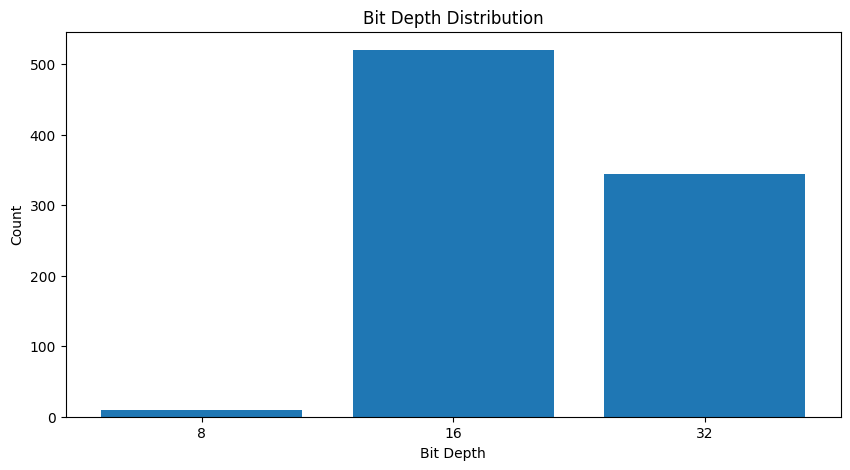

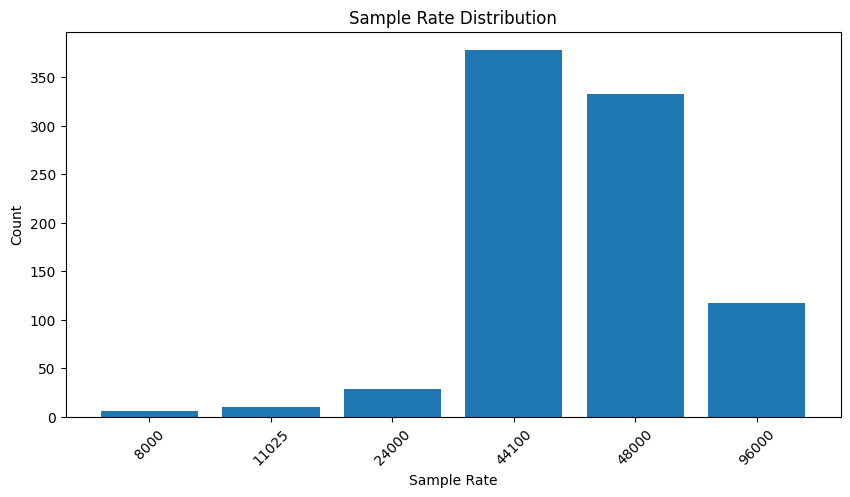

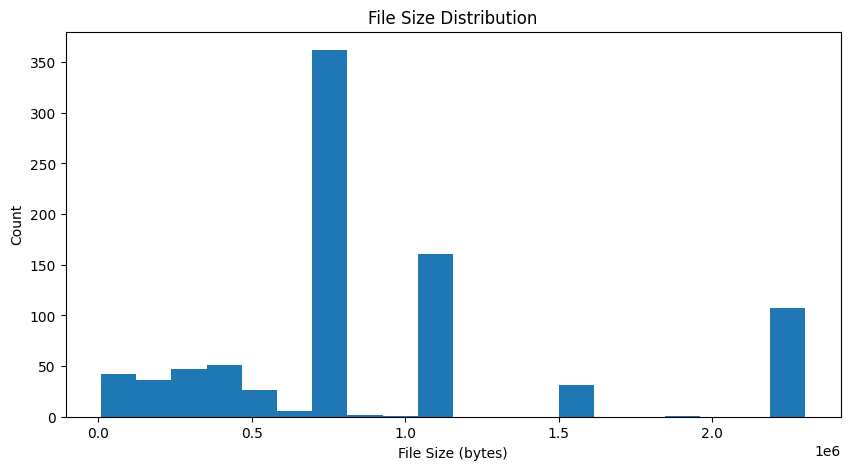

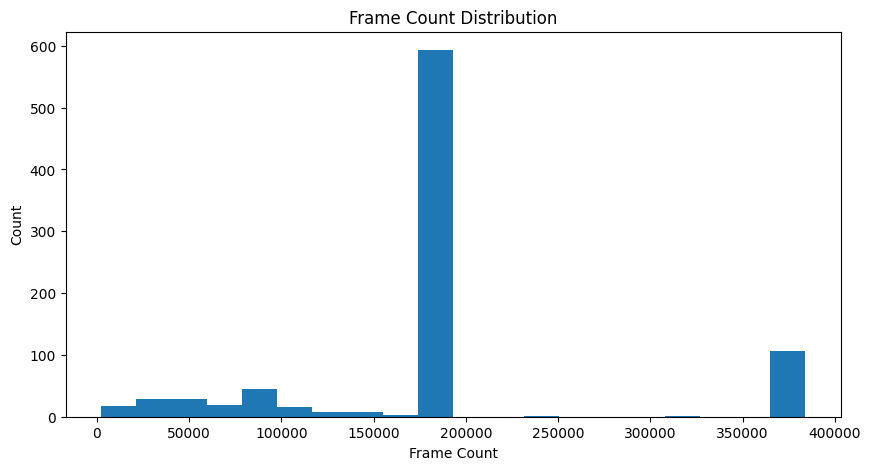

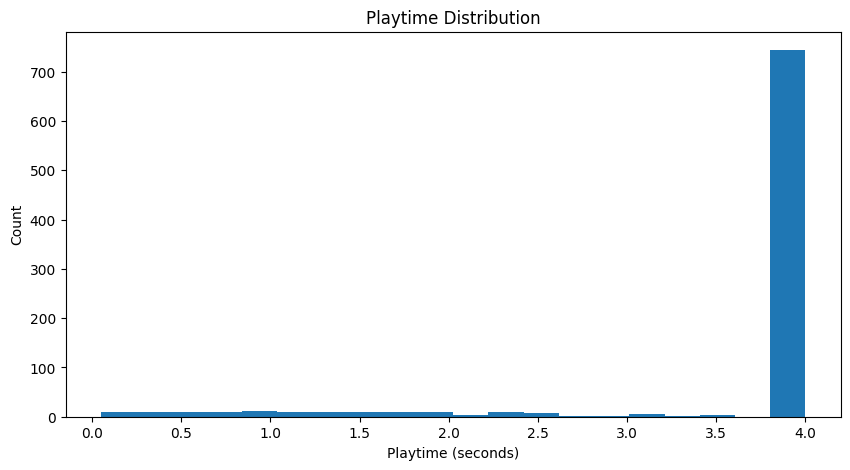

In [6]:
def _log_and_raise(message: str, exception: type[Exception] | Exception) -> None:
    logger.error(f"{message} {exception}")
    if isinstance(exception, type):
        raise exception(message)
    raise exception

def load_dataset(path: Path) -> np.ndarray:
    '''
        Loads the dataset located at path.

        Args:
            path: Absolute path to the folder containing the dataset

        Returns:
            nd.array containing file data corresponding to the entire dataset
    '''
    logger.info(f"Loading dataset from {path}")
    dataset: list[tuple[np.ndarray, Metadata]] = []

    if not path.exists():
        _log_and_raise(f"Dataset path {path} not found", FileNotFoundError)

    if not path.is_dir():
        _log_and_raise(f"Dataset path {path} is not a directory", TypeError)

    metadata = load_csv(path / "UrbanSound8K.csv")

    for file in path.glob(GLOB):
        try:
            dataset.append(load_wav(file, metadata))
            dataset[-1] = (np.zeros_like(dataset[-1][0]), dataset[-1][1])

            #if not validate_wav(dataset[-1][1]): #TODO: not
            #    logger.warning(f"Unexpected wav metadata for file {file}")
        except Exception as e:
            logger.warning(f"Skipping {file}, failed to load: {e}")

    audit_dataset([metadata for _, metadata in dataset])
    return np.array([data for data, _ in dataset], dtype=object)



def load_wav(path: Path, dataset_: list[dict]) -> tuple[np.ndarray, Metadata]:
    '''
        Loads and validates the contents of a single .wav file.

        Args:
            path: Absolute path to the .wav file.

        Returns:
            (ndarray, Metadata) a numpy array with wav data and metadata
        
        Raises:
            FileNotFoundError
            RuntimeError
            TypeError

    '''
    if not path.exists():
        _log_and_raise(f"File {path} not found", FileNotFoundError)

    if not path.is_file():
        _log_and_raise(f"File {path} is not a file", TypeError)

    if path.suffix.lower() != ".wav":
        _log_and_raise(f"File {path} is not a .wav file", TypeError) #TODO: Consider changing as .wav extension in name is a windows specific limitation

    try:
        samplerate, data = _read_wav(path)
        metadata = get_metadata(path, samplerate, data)
        return data, metadata
    except Exception as e:
        _log_and_raise(f"Failed to load wav file {path}", e)



def _read_wav(path: Path) -> tuple[int, np.ndarray]:
    '''
        Computes and returns metadata from wav file contents.

        Args:
            path: Absolute path to the .wav file.

        Returns:
            (samplerate, ndarray) the sample rate and decoded sample data
    '''
    try:
        return wavfile.read(path)
    except ValueError:
        data, samplerate = sf.read(path, dtype="int16")
        return samplerate, data


def get_metadata(path: Path, samplerate: int, data: np.ndarray) -> Metadata:
    '''
        Computes and returns metadata from already-read wav file contents.

        Args:
            path: Absolute path to the .wav file.
            samplerate: Sample rate of the wav file.
            data: Decoded sample data of the wav file.

        Returns:
            Metadata class containing metadata extracted from the wav file
    '''
    return Metadata(
        file_name = path.name,
        bit_depth = data.dtype.itemsize * 8,
        channel_count = data.shape[1] if data.ndim > 1 else 1,
        label = CLASSES.UNKNOWN, #TODO: add look up in csv for class/label
        file_size = path.stat().st_size,
        frame_count = data.shape[0],
        sample_rate = samplerate
    )

def load_csv(path: Path) -> list[dict]:
    '''
        Loads and validates the contents of a CSV file.

        Args:
            path: Absolute path to the CSV file.

        Returns:
            List of dictionaries containing CSV data.

        Raises:
            FileNotFoundError
            RuntimeError
            TypeError
    '''
    if not path.exists():
        _log_and_raise(f"File {path} not found", FileNotFoundError)

    if not path.is_file():
        _log_and_raise(f"File {path} is not a file", TypeError)

    if path.suffix.lower() != ".csv":
        _log_and_raise(f"File {path} is not a .csv file", TypeError)

    try:
        with open(path, newline='') as csvfile:
            reader = csv.DictReader(csvfile)
            return [row for row in reader]
    except Exception as e:
        _log_and_raise(f"Failed to read CSV file {path}", e)


def validate_wav(metadata: Metadata) -> bool:
    '''
        Validates the metadata of a wav file.

        Args:
            metadata: Metadata object containing wav file information.

        Returns:
            True if the wav file metadata is valid, False otherwise.
    '''
    issue = False
    logger.info(f"Validating wav metadata for file: {metadata.file_name}")

    if metadata.bit_depth not in BITDEPTHS:
        logger.warning(f"\tUnexpected bit depth: {metadata.bit_depth}")
        issue = True
    if metadata.channel_count not in CHANNELS:
        logger.warning(f"\tUnexpected channel count: {metadata.channel_count}")
        issue = True
    if metadata.frame_count <= 0:
        logger.warning(f"\tInvalid frame count: {metadata.frame_count}")
        issue = True
    if metadata.sample_rate not in SAMPLING_RATES:
        logger.warning(f"\tInvalid sample rate: {metadata.sample_rate}")
        issue = True
    return not issue


def audit_dataset(dataset: list[Metadata]) -> None:
    statistics = {
        "filecount": 0,
        "valid": 0,
        "bitdepth_counts":dict(),
        "average_bit_depth": 0,

        "sample_rate_counts": dict(),
        "average_sample_rate": 0,

        "single_channel_files": 0,

        "file_sizes": [],
        "average_file_size": 0,
        "total_file_size": 0,
        
        "frame_counts": [],
        "average_frame_count": 0,
        "playtimes": [],
        "average_playtime": 0.0,
        "total_playtime": 0.0,
        
    }
    for metadata in dataset:
        statistics["filecount"] += 1
        #if validate_wav(metadata):
        statistics["valid"] += 1 #TODO: gate
        if statistics["bitdepth_counts"].get(metadata.bit_depth) is None:
            statistics["bitdepth_counts"][metadata.bit_depth] = 0
        statistics["bitdepth_counts"][metadata.bit_depth] = statistics["bitdepth_counts"].get(metadata.bit_depth, 0) + 1
        if statistics["sample_rate_counts"].get(metadata.sample_rate) is None:
            statistics["sample_rate_counts"][metadata.sample_rate] = 0
        statistics["sample_rate_counts"][metadata.sample_rate] = statistics["sample_rate_counts"].get(metadata.sample_rate, 0) + 1
        if metadata.channel_count == 1:
            statistics["single_channel_files"] += 1
        statistics["file_sizes"].append(metadata.file_size)
        statistics["total_file_size"] += metadata.file_size
        statistics["frame_counts"].append(metadata.frame_count)
        playtime = metadata.frame_count / metadata.sample_rate
        statistics["playtimes"].append(playtime)
        statistics["total_playtime"] += playtime

    statistics["average_bit_depth"] = sum([k * v for k, v in statistics["bitdepth_counts"].items()]) / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_sample_rate"] = sum([k * v for k, v in statistics["sample_rate_counts"].items()]) / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_file_size"] = statistics["total_file_size"] / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_frame_count"] = sum(statistics["frame_counts"]) / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_playtime"] = statistics["total_playtime"] / statistics["filecount"] if statistics["filecount"] > 0 else 0

    print({k: v for k, v in statistics.items() if k not in ("file_sizes", "frame_counts", "playtimes")})

    visualize_audit(statistics)
    return

def _plot_counts(counts: dict, title: str, xlabel: str, rotation: int = 0) -> None:
    labels = sorted(counts.keys())
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(labels)), [counts[k] for k in labels])
    plt.xticks(range(len(labels)), labels, rotation=rotation)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()


def _plot_histogram(values: list, title: str, xlabel: str) -> None:
    plt.figure(figsize=(10, 5))
    plt.hist(sorted(values), bins=20)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()


def visualize_audit(statistics: dict) -> None:
    _plot_counts(statistics["bitdepth_counts"], "Bit Depth Distribution", "Bit Depth")
    _plot_counts(statistics["sample_rate_counts"], "Sample Rate Distribution", "Sample Rate", rotation=45)
    _plot_histogram(statistics["file_sizes"], "File Size Distribution", "File Size (bytes)")
    _plot_histogram(statistics["frame_counts"], "Frame Count Distribution", "Frame Count")
    _plot_histogram(statistics["playtimes"], "Playtime Distribution", "Playtime (seconds)")

_ = load_dataset(DATASET_PATH)

### 3.) Time and frequency domain view

One representative clip from fold1, viewed as a waveform (time domain) and as a magnitude spectrum via FFT (frequency domain).

In [ ]:
def plot_time_and_frequency(path: Path) -> None:
    samplerate, data = _read_wav(path)
    if data.ndim > 1:
        data = data[:, 0] #Use one channel so the spectrum isn't mixed across channels

    duration = data.shape[0] / samplerate
    time = np.linspace(0, duration, data.shape[0], endpoint=False)

    plt.figure(figsize=(10, 4))
    plt.plot(time, data)
    plt.title(f"Time Domain: {path.name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    spectrum = np.fft.rfft(data)
    freqs = np.fft.rfftfreq(data.shape[0], d=1 / samplerate)
    magnitude = np.abs(spectrum)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, magnitude)
    plt.title(f"Frequency Domain: {path.name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.show()


sample_file = next(DATASET_PATH.glob(GLOB))
plot_time_and_frequency(sample_file)